# Clean vs Distribution Shift Comparison:
# Ridge, Lasso, and OT-DRO

## Goal

In this notebook, we compare three models:

1. Ridge regression
2. Lasso regression
3. OT-DRO robust linear regression

We train all models on clean data and then test them under:

- clean test data
- mild distribution shift
- moderate distribution shift
- strong distribution shift

This lets us study how each method behaves as the test distribution moves away from the training distribution.

## Main question

Does the OT-based robust method generalize better than ridge and lasso when the test distribution shifts?

# OT-DRO model used in this notebook

We use the OT-derived robust objective

$$
\min_{\theta,b}
\frac{1}{n}\sum_{i=1}^n |y_i-(x_i^\top\theta+b)|
+
\kappa \|\theta\|_2
$$

where:
- $\theta$ is the coefficient vector
- $b$ is the intercept
- $\kappa$ is the effective robustness parameter

This comes from the OT-DRO formulation with:

$$
\psi(t)=\alpha t^2
$$

whose Legendre transform is

$$
\psi^*(u)=\frac{u^2}{4\alpha}
$$

and the full robust objective reduces to the estimator above, with

$$
\kappa = \delta + \sqrt{\frac{\epsilon}{\alpha}}
$$

So in practice, we tune $\kappa$ directly.

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import cvxpy as cp

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Synthetic data generation

We create data from a linear model

$$
y = X\theta^* + b^* + \eta
$$

where $\eta$ is Gaussian noise.

All models are trained on clean training data.
Only the test features are shifted.

In [4]:
def generate_linear_data(n=800, d=20, noise_std=1.0, seed=42, sparse=False):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, d))

    if sparse:
        beta_true = np.zeros(d)
        idx = rng.choice(d, size=max(3, d // 5), replace=False)
        beta_true[idx] = rng.normal(0, 3, size=len(idx))
    else:
        beta_true = rng.normal(0, 2, size=d)

    intercept_true = 1.5
    y = X @ beta_true + intercept_true + rng.normal(0, noise_std, size=n)

    return X, y, beta_true, intercept_true

# Shift functions

We test several test-time shifts.

If the original features are $X$, then the shifted features are:

- mild shift: small mean shift
- moderate shift: moderate mean and scale shift
- strong shift: larger mean and scale shift

These are all valid covariate shifts.

In [5]:
def apply_shift(X, shift_type="clean"):
    X_new = X.copy()

    if shift_type == "clean":
        return X_new

    elif shift_type == "mild_mean":
        return X_new + 0.25

    elif shift_type == "moderate_mean_scale":
        return X_new * 1.10 + 0.50

    elif shift_type == "strong_mean_scale":
        return X_new * 1.50 + 1.00

    else:
        raise ValueError(f"Unknown shift_type: {shift_type}")

# Data splitting and scaling

We split the data into:
- training set
- validation set
- test set

Important:
The scaler is fit only on the clean training data.
This means the shifted test sets remain shifted after standardization, which is exactly what we want.

In [13]:
def split_and_scale(X, y, seed=42):
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.25, random_state=seed
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, scaler, X_test

# Ridge and lasso

We tune ridge and lasso on the clean validation set.
The selected hyperparameters are then kept fixed when evaluating on shifted test sets.

In [7]:
def fit_ridge_tuned(X_train, y_train, X_val, y_val, alphas):
    best_model = None
    best_alpha = None
    best_mae = np.inf
    t0 = time.perf_counter()

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)

        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha
            best_model = model

    elapsed = time.perf_counter() - t0
    return best_model, best_alpha, elapsed


def fit_lasso_tuned(X_train, y_train, X_val, y_val, alphas):
    best_model = None
    best_alpha = None
    best_mae = np.inf
    t0 = time.perf_counter()

    for alpha in alphas:
        model = Lasso(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)

        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha
            best_model = model

    elapsed = time.perf_counter() - t0
    return best_model, best_alpha, elapsed

# OT-DRO model

We solve

$$
\min_{\theta,b}
\frac{1}{n}\sum_{i=1}^n |y_i-(x_i^\top\theta+b)|
+
\kappa \|\theta\|_2
$$

with CVXPY.

We tune $\kappa$ on the clean validation set.

In [8]:
class OTDRORegressor:
    def __init__(self, kappa=1.0):
        self.kappa = kappa
        self.beta_ = None
        self.intercept_ = None
        self.solve_time_ = None
        self.status_ = None

    def fit(self, X, y):
        n, d = X.shape

        beta = cp.Variable(d)
        b = cp.Variable()

        residuals = y - (X @ beta + b)

        objective = cp.Minimize(
            (1 / n) * cp.norm1(residuals) + self.kappa * cp.norm(beta, 2)
        )

        problem = cp.Problem(objective)

        t0 = time.perf_counter()
        problem.solve(solver=cp.SCS, verbose=False)
        self.solve_time_ = time.perf_counter() - t0
        self.status_ = problem.status

        if beta.value is None or b.value is None:
            raise RuntimeError(f"OT-DRO solver failed with status: {problem.status}")

        self.beta_ = beta.value
        self.intercept_ = b.value
        return self

    def predict(self, X):
        return X @ self.beta_ + self.intercept_


def fit_otdro_tuned(X_train, y_train, X_val, y_val, kappas):
    best_model = None
    best_kappa = None
    best_mae = np.inf
    t0 = time.perf_counter()

    for kappa in kappas:
        model = OTDRORegressor(kappa=kappa)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)

        if mae < best_mae:
            best_mae = mae
            best_kappa = kappa
            best_model = model

    elapsed = time.perf_counter() - t0
    return best_model, best_kappa, elapsed

# Evaluation metrics

We report:
- MAE
- RMSE
- $R^2$
- training time

In [9]:
def evaluate_model(model, X_test, y_test, model_name, train_time, scenario):
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return {
        "scenario": scenario,
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "train_time_sec": train_time
    }

# Main experiment

Procedure for one random seed:

1. generate clean data
2. split into train/validation/test
3. tune ridge, lasso, and OT-DRO on the clean validation set
4. evaluate the same fitted models on:
   - clean test data
   - mildly shifted test data
   - moderately shifted test data
   - strongly shifted test data

This isolates the effect of distribution shift.

In [11]:
def run_clean_vs_shift_experiment(seed=42):
    X, y, beta_true, intercept_true = generate_linear_data(
        n=800, d=20, noise_std=1.0, seed=seed, sparse=False
    )

    X_train, X_val, X_test_clean_scaled, y_train, y_val, y_test, scaler, X_test_raw = split_and_scale(X, y, seed=seed)

    ridge_alphas = np.logspace(-3, 2, 12)
    lasso_alphas = np.logspace(-3, 1, 12)
    kappas = np.logspace(-3, 1, 12)

    ridge_model, ridge_alpha, ridge_time = fit_ridge_tuned(X_train, y_train, X_val, y_val, ridge_alphas)
    lasso_model, lasso_alpha, lasso_time = fit_lasso_tuned(X_train, y_train, X_val, y_val, lasso_alphas)
    otdro_model, best_kappa, otdro_time = fit_otdro_tuned(X_train, y_train, X_val, y_val, kappas)

    models = [
        (ridge_model, f"Ridge(alpha={ridge_alpha:.4f})", ridge_time),
        (lasso_model, f"Lasso(alpha={lasso_alpha:.4f})", lasso_time),
        (otdro_model, f"OT-DRO(kappa={best_kappa:.4f})", otdro_time),
    ]

    scenarios = ["clean", "mild_mean", "moderate_mean_scale", "strong_mean_scale"]

    rows = []
    for scenario in scenarios:
        X_test_shifted_raw = apply_shift(X_test_raw, shift_type=scenario)
        X_test_shifted_scaled = scaler.transform(X_test_shifted_raw)

        for model, model_name, train_time in models:
            rows.append(
                evaluate_model(
                    model=model,
                    X_test=X_test_shifted_scaled,
                    y_test=y_test,
                    model_name=model_name,
                    train_time=train_time,
                    scenario=scenario
                )
            )

    return pd.DataFrame(rows)

In [12]:
one_seed_results = run_clean_vs_shift_experiment(seed=42)
display(one_seed_results.sort_values(["scenario", "MAE"]).reset_index(drop=True))

,scenario,model,MAE,RMSE,R2,train_time_sec
0,clean,Ridge(alpha=0.0010),0.816418,1.007308,0.980163,0.020479
1,clean,Lasso(alpha=0.0010),0.816618,1.007155,0.980169,0.016187
2,clean,OT-DRO(kappa=0.0123),0.839642,1.033861,0.979103,1.129807
3,mild_mean,Lasso(alpha=0.0010),0.975674,1.230385,0.970404,0.016187
4,mild_mean,Ridge(alpha=0.0010),0.975687,1.230573,0.970395,0.020479
5,mild_mean,OT-DRO(kappa=0.0123),0.978060,1.232127,0.970320,1.129807
6,moderate_mean_scale,OT-DRO(kappa=0.0123),1.531010,1.879447,0.930942,1.129807
7,moderate_mean_scale,Lasso(alpha=0.0010),1.543161,1.894584,0.929825,0.016187
8,moderate_mean_scale,Ridge(alpha=0.0010),1.544283,1.896232,0.929703,0.020479
9,strong_mean_scale,Lasso(alpha=0.0010),3.822118,4.713470,0.565653,0.016187


# Repeat across several seeds

To make the comparison more reliable, we repeat the experiment across multiple random seeds and summarize the mean and standard deviation.

In [14]:
def run_repeated_clean_vs_shift(seeds=(1, 2, 3, 4, 5)):
    frames = []
    for seed in seeds:
        df = run_clean_vs_shift_experiment(seed=seed)
        df["seed"] = seed
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def summarize_results(df):
    numeric_cols = ["MAE", "RMSE", "R2", "train_time_sec"]
    summary = df.groupby(["scenario", "model"])[numeric_cols].agg(["mean", "std"])
    return summary

In [15]:
all_results = run_repeated_clean_vs_shift(seeds=(1, 2, 3, 4, 5))
summary = summarize_results(all_results)

display(summary)

MAE                 RMSE                  R2           train_time_sec          
                                               mean       std       mean       std      mean       std           mean       std
scenario            model                                                                                                      
clean               Lasso(alpha=0.0010)    0.833960       NaN   1.028013       NaN  0.976902       NaN       0.008155       NaN
                    Lasso(alpha=0.0123)    0.832032  0.036478   1.044237  0.059347  0.989917  0.002468       0.008140  0.000061
                    Lasso(alpha=0.0285)    0.833897  0.073524   1.043733  0.023333  0.978294  0.002678       0.009555  0.002391
                    OT-DRO(kappa=0.0023)   0.858965       NaN   1.093760       NaN  0.988007       NaN       1.236723       NaN
                    OT-DRO(kappa=0.0053)   0.844610       NaN   1.040877       NaN  0.976320       NaN       1.032761       NaN
                    OT-DRO(kappa=0.1520)   0.849043  0.078937   1.061217  0.045230  0.981780  0.008439       1.313913  0.341588
                    Ridge(alpha=0.0010)    0.833842       NaN   1.027800       NaN  0.976912       NaN       0.010026       NaN
                    Ridge(alpha=1.5199)    0.858252       NaN   1.086271       NaN  0.988170       NaN       0.008955       NaN
                    Ridge(alpha=4.3288)    0.824160  0.051717   1.032027  0.020793  0.982772  0.007728       0.011079  0.002708
mild_mean           Lasso(alpha=0.0010)    1.617002       NaN   1.853952       NaN  0.924877       NaN       0.008155       NaN
                    Lasso(alpha=0.0123)    2.455328  0.806757   2.660762  0.777621  0.929838  0.046923       0.008140  0.000061
                    Lasso(alpha=0.0285)    3.765370  2.127833   3.924842  2.050329  0.639264  0.347500       0.009555  0.002391
                    OT-DRO(kappa=0.0023)   3.064846       NaN   3.252858       NaN  0.893921       NaN       1.236723       NaN
                    OT-DRO(kappa=0.0053)   1.639289       NaN   1.888744       NaN  0.922031       NaN       1.032761       NaN
                    OT-DRO(kappa=0.1520)   3.088917  1.889744   3.282096  1.819080  0.749902  0.310559       1.313913  0.341588
                    Ridge(alpha=0.0010)    1.617564       NaN   1.854167       NaN  0.924859       NaN       0.010026       NaN
                    Ridge(alpha=1.5199)    3.034656       NaN   3.219553       NaN  0.896082       NaN       0.008955       NaN
                    Ridge(alpha=4.3288)    3.133370  1.881394   3.316495  1.811941  0.746328  0.312705       0.011079  0.002708
moderate_mean_scale Lasso(alpha=0.0010)    3.048418       NaN   3.264381       NaN  0.767095       NaN       0.008155       NaN
                    Lasso(alpha=0.0123)    4.900457  1.419954   5.091945  1.422960  0.744318  0.165648       0.008140  0.000061
                    Lasso(alpha=0.0285)    7.350182  4.156728   7.472927  4.075732 -0.323408  1.311932       0.009555  0.002391
                    OT-DRO(kappa=0.0023)   5.983853       NaN   6.189314       NaN  0.615954       NaN       1.236723       NaN
                    OT-DRO(kappa=0.0053)   3.103775       NaN   3.321777       NaN  0.758833       NaN       1.032761       NaN
                    OT-DRO(kappa=0.1520)   6.080082  3.581507   6.213589  3.522815  0.095511  1.140916       1.313913  0.341588
                    Ridge(alpha=0.0010)    3.049999       NaN   3.266406       NaN  0.766806       NaN       0.010026       NaN
                    Ridge(alpha=1.5199)    5.922814       NaN   6.117855       NaN  0.624771       NaN       0.008955       NaN
                    Ridge(alpha=4.3288)    6.193060  3.610385   6.337770  3.544015  0.065704  1.171840       0.011079  0.002708
strong_mean_scale   Lasso(alpha=0.0010)    6.139273       NaN   6.913915       NaN -0.044782       NaN       0.008155       NaN
                    Lasso(alpha=0.0123)    9.896486  2.510422  11.044077  2.3065

# Scenario-wise tables

In [16]:
scenarios = ["clean", "mild_mean", "moderate_mean_scale", "strong_mean_scale"]

for scenario in scenarios:
    print(f"\nScenario: {scenario}")
    display(
        all_results[all_results["scenario"] == scenario]
        .groupby("model")[["MAE", "RMSE", "R2", "train_time_sec"]]
        .agg(["mean", "std"])
        .sort_values(("MAE", "mean"))
    )


Scenario: clean


MAE                RMSE                  R2           train_time_sec          
                          mean       std      mean       std      mean       std           mean       std
model                                                                                                    
Ridge(alpha=4.3288)   0.824160  0.051717  1.032027  0.020793  0.982772  0.007728       0.011079  0.002708
Lasso(alpha=0.0123)   0.832032  0.036478  1.044237  0.059347  0.989917  0.002468       0.008140  0.000061
Ridge(alpha=0.0010)   0.833842       NaN  1.027800       NaN  0.976912       NaN       0.010026       NaN
Lasso(alpha=0.0285)   0.833897  0.073524  1.043733  0.023333  0.978294  0.002678       0.009555  0.002391
Lasso(alpha=0.0010)   0.833960       NaN  1.028013       NaN  0.976902       NaN       0.008155       NaN
OT-DRO(kappa=0.0053)  0.844610       NaN  1.040877       NaN  0.976320       NaN       1.032761       NaN
OT-DRO(kappa=0.1520)  0.849043  0.078937  1.061217  0.045230  0.981780  0.008439       1.313913  0.341588
Ridge(alpha=1.5199)   0.858252       NaN  1.086271       NaN  0.988170       NaN       0.008955       NaN
OT-DRO(kappa=0.0023)  0.858965       NaN  1.093760       NaN  0.988007       NaN       1.236723       NaN


Scenario: mild_mean


MAE                RMSE                  R2           train_time_sec          
                          mean       std      mean       std      mean       std           mean       std
model                                                                                                    
Lasso(alpha=0.0010)   1.617002       NaN  1.853952       NaN  0.924877       NaN       0.008155       NaN
Ridge(alpha=0.0010)   1.617564       NaN  1.854167       NaN  0.924859       NaN       0.010026       NaN
OT-DRO(kappa=0.0053)  1.639289       NaN  1.888744       NaN  0.922031       NaN       1.032761       NaN
Lasso(alpha=0.0123)   2.455328  0.806757  2.660762  0.777621  0.929838  0.046923       0.008140  0.000061
Ridge(alpha=1.5199)   3.034656       NaN  3.219553       NaN  0.896082       NaN       0.008955       NaN
OT-DRO(kappa=0.0023)  3.064846       NaN  3.252858       NaN  0.893921       NaN       1.236723       NaN
OT-DRO(kappa=0.1520)  3.088917  1.889744  3.282096  1.819080  0.749902  0.310559       1.313913  0.341588
Ridge(alpha=4.3288)   3.133370  1.881394  3.316495  1.811941  0.746328  0.312705       0.011079  0.002708
Lasso(alpha=0.0285)   3.765370  2.127833  3.924842  2.050329  0.639264  0.347500       0.009555  0.002391


Scenario: moderate_mean_scale


MAE                RMSE                  R2           train_time_sec          
                          mean       std      mean       std      mean       std           mean       std
model                                                                                                    
Lasso(alpha=0.0010)   3.048418       NaN  3.264381       NaN  0.767095       NaN       0.008155       NaN
Ridge(alpha=0.0010)   3.049999       NaN  3.266406       NaN  0.766806       NaN       0.010026       NaN
OT-DRO(kappa=0.0053)  3.103775       NaN  3.321777       NaN  0.758833       NaN       1.032761       NaN
Lasso(alpha=0.0123)   4.900457  1.419954  5.091945  1.422960  0.744318  0.165648       0.008140  0.000061
Ridge(alpha=1.5199)   5.922814       NaN  6.117855       NaN  0.624771       NaN       0.008955       NaN
OT-DRO(kappa=0.0023)  5.983853       NaN  6.189314       NaN  0.615954       NaN       1.236723       NaN
OT-DRO(kappa=0.1520)  6.080082  3.581507  6.213589  3.522815  0.095511  1.140916       1.313913  0.341588
Ridge(alpha=4.3288)   6.193060  3.610385  6.337770  3.544015  0.065704  1.171840       0.011079  0.002708
Lasso(alpha=0.0285)   7.350182  4.156728  7.472927  4.075732 -0.323408  1.311932       0.009555  0.002391


Scenario: strong_mean_scale


MAE                 RMSE                  R2           train_time_sec          
                           mean       std       mean       std      mean       std           mean       std
model                                                                                                      
Lasso(alpha=0.0010)    6.139273       NaN   6.913915       NaN -0.044782       NaN       0.008155       NaN
Ridge(alpha=0.0010)    6.143388       NaN   6.919396       NaN -0.046439       NaN       0.010026       NaN
OT-DRO(kappa=0.0053)   6.234723       NaN   7.007121       NaN -0.073141       NaN       1.032761       NaN
Lasso(alpha=0.0123)    9.896486  2.510422  11.044077  2.306588 -0.173023  0.618888       0.008140  0.000061
Ridge(alpha=1.5199)   11.710825       NaN  12.714946       NaN -0.620790       NaN       0.008955       NaN
OT-DRO(kappa=0.0023)  11.832129       NaN  12.856730       NaN -0.657138       NaN       1.236723       NaN
OT-DRO(kappa=0.1520)  12.028953  6.733142  12.770310  6.311912 -2.570922  4.246559       1.313913  0.341588
Ridge(alpha=4.3288)   12.281952  6.828724  13.052012  6.403776 -2.716580  4.406632       0.011079  0.002708
Lasso(alpha=0.0285)   14.373022  7.995416  14.880164  7.670631 -4.166967  4.932843       0.009555  0.002391

# Plot MAE across clean and shifted settings

In [17]:
def plot_metric_by_scenario(all_results, metric="MAE"):
    agg = (
        all_results
        .groupby(["scenario", "model"])[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    scenario_order = ["clean", "mild_mean", "moderate_mean_scale", "strong_mean_scale"]

    for scenario in scenario_order:
        subset = agg[agg["scenario"] == scenario]

        plt.figure(figsize=(8, 4))
        plt.bar(subset["model"], subset["mean"], yerr=subset["std"], capsize=4)
        plt.title(f"{metric} under {scenario}")
        plt.ylabel(metric)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.show()

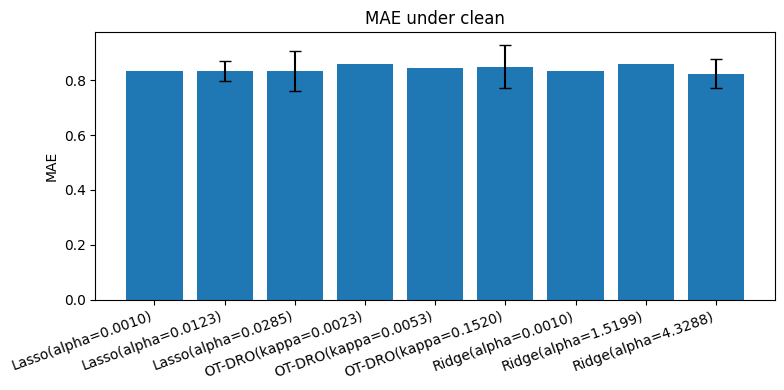

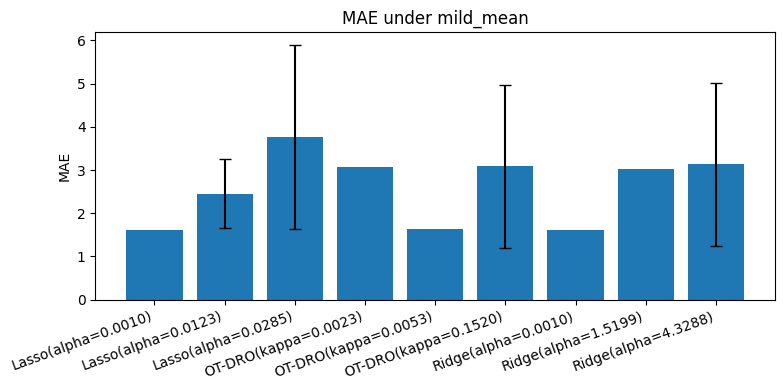

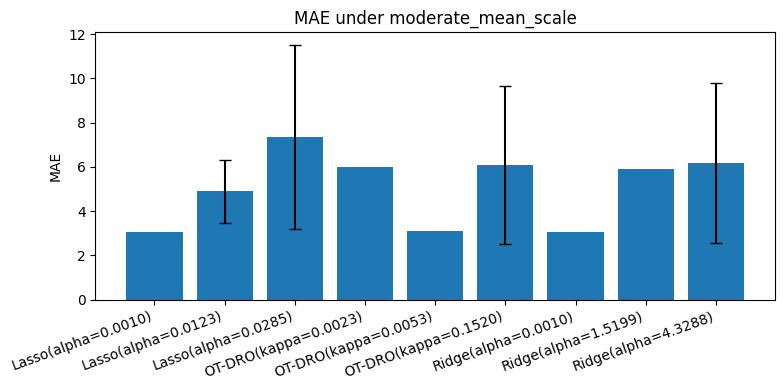

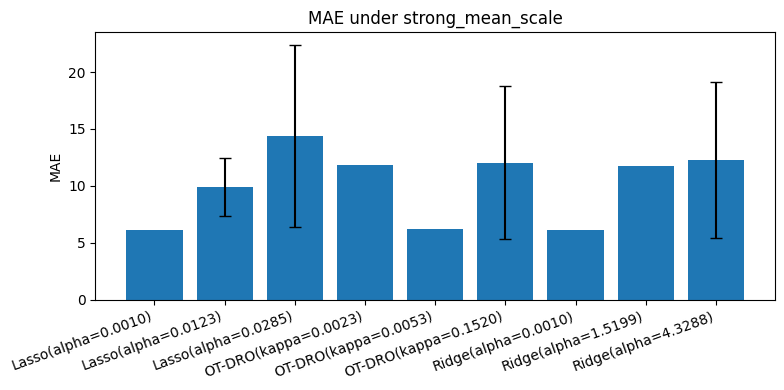

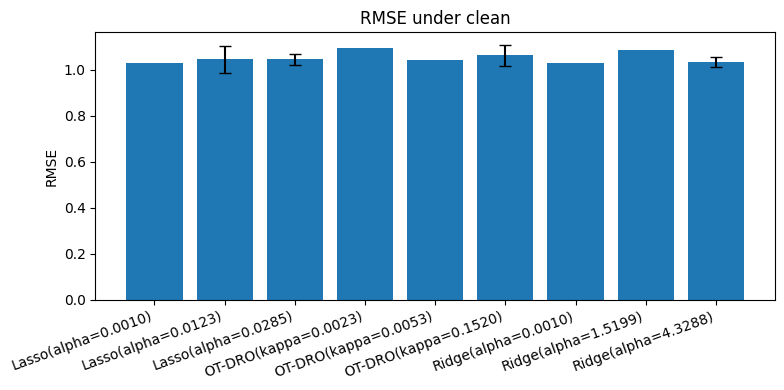

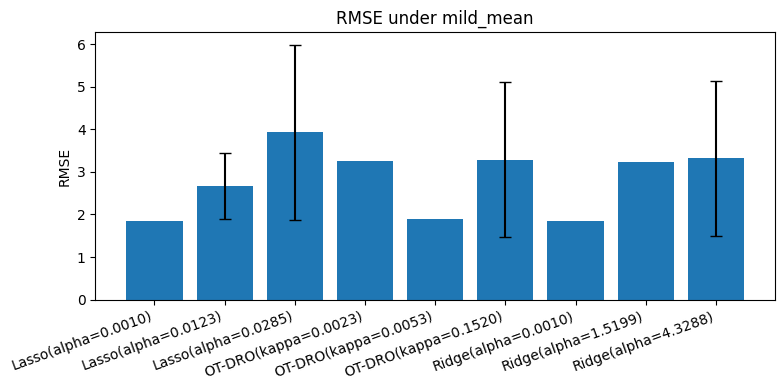

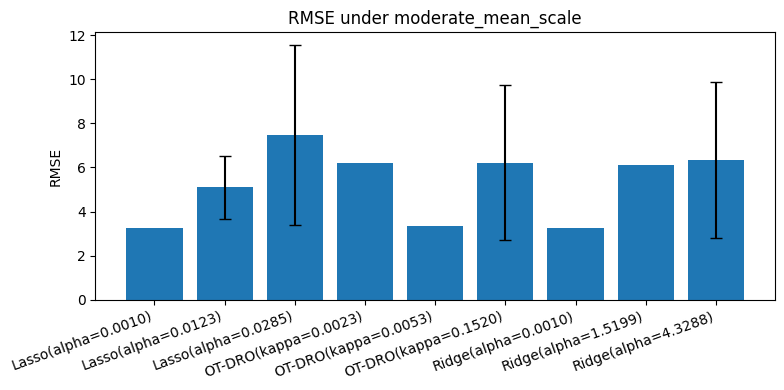

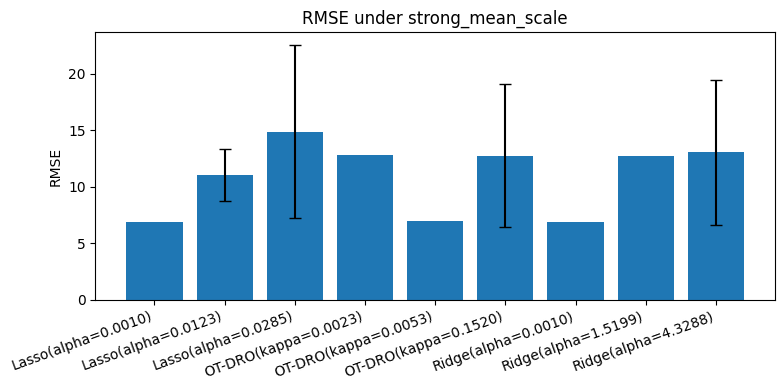

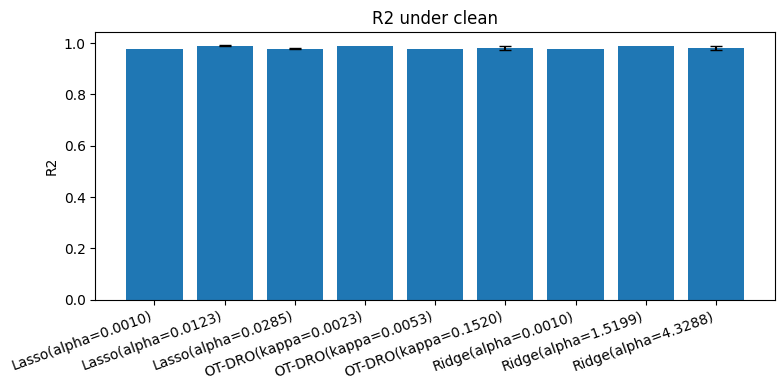

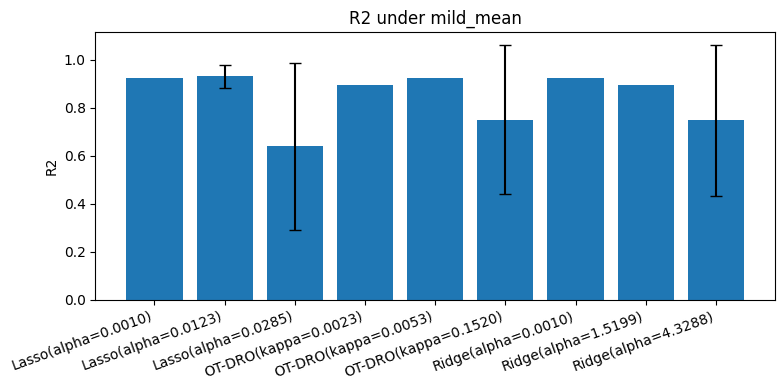

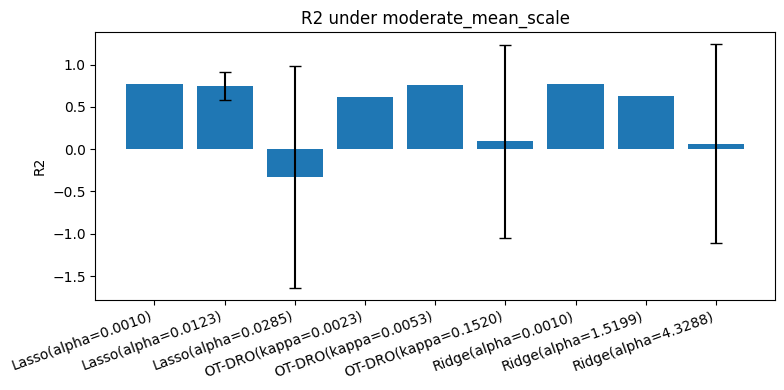

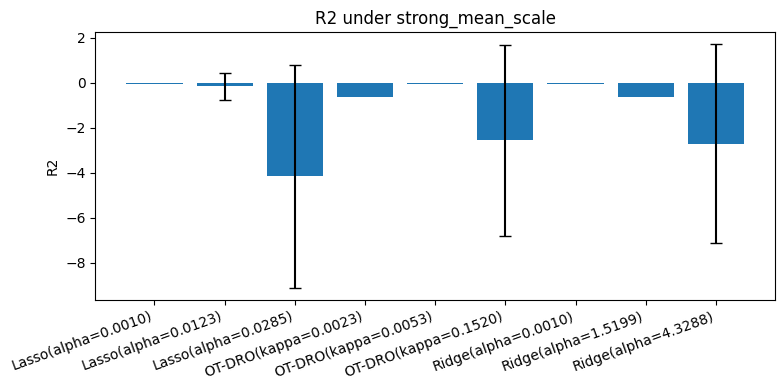

In [18]:
plot_metric_by_scenario(all_results, metric="MAE")
plot_metric_by_scenario(all_results, metric="RMSE")
plot_metric_by_scenario(all_results, metric="R2")

# Plot how each model degrades as shift becomes stronger

This view makes it easier to see whether one model is more stable under increasing shift severity.

In [21]:
def plot_degradation_curve(all_results, metric="MAE"):
    agg = (
        all_results
        .groupby(["scenario", "model"])[metric]
        .mean()
        .reset_index()
    )

    scenario_order = ["clean", "mild_mean", "moderate_mean_scale", "strong_mean_scale"]
    scenario_to_x = {name: i for i, name in enumerate(scenario_order)}
    agg["x"] = agg["scenario"].map(scenario_to_x)

    plt.figure(figsize=(8, 5))

    for model_name in agg["model"].unique():
        subset = agg[agg["model"] == model_name].sort_values("x")
        plt.plot(subset["x"], subset["mean"], marker="o", label=model_name)

    plt.xticks(range(len(scenario_order)), scenario_order, rotation=20)
    plt.ylabel(metric)
    plt.title(f"{metric} as shift severity increases")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
plot_degradation_curve(all_results, metric="MAE")
plot_degradation_curve(all_results, metric="RMSE")

KeyError: 'mean'

<Figure size 800x500 with 0 Axes>